# Lab 2: Predictive Analytics with Machine Learning

**Name:** Yaa Waadu Asomaning

**Course:** Intro to AI

**Student ID:** 10552028

**Date:** 03/06/2026

In [29]:
# Numerical computations
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

RANDOM_STATE = 42

TAXI_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

In [30]:
taxi = pd.read_csv(TAXI_URL)

print("Shape:", taxi.shape)

display(taxi.head())

Shape: (41202, 13)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


In [31]:
taxi.info()

display(taxi.describe())

print("\nMissing values:")
display(taxi.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000



Missing values:


VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64

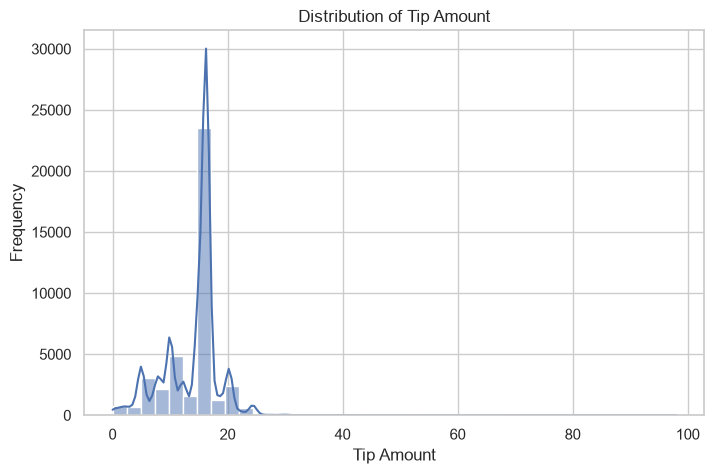

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(taxi["tip_amount"], bins=40, kde=True)

plt.title("Distribution of Tip Amount")
plt.xlabel("Tip Amount")
plt.ylabel("Frequency")

plt.show()

In [33]:
X = taxi.drop(columns=["tip_amount"])
y = taxi["tip_amount"]

print("Features:", X.shape)
print("Target:", y.shape)

print("\nMissing values in X:")
print(X.isna().sum())

Features: (41202, 12)
Target: (41202,)

Missing values in X:
VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
dtype: int64


In [34]:
# First split: 60% train, 40% temporary

X_train, X_temp, y_train, y_temp = train_test_split(

    X,

    y,

    test_size=0.40,

    random_state=RANDOM_STATE

)

# Second split: 20% validation, 20% test

X_val, X_test, y_val, y_test = train_test_split(

    X_temp,

    y_temp,

    test_size=0.50,

    random_state=RANDOM_STATE

)

print("Training:", X_train.shape)

print("Validation:", X_val.shape)

print("Testing:", X_test.shape)

Training: (24721, 12)
Validation: (8240, 12)
Testing: (8241, 12)


In [35]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [36]:
print(np.isnan(X_train_scaled).sum())

print(np.isnan(X_val_scaled).sum())

print(np.isnan(X_test_scaled).sum())

0
0
0


In [37]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE
)

rf.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [38]:
def evaluate_model(model, X, y):
    predictions = model.predict(X)

    rmse = np.sqrt(mean_squared_error(y, predictions))
    r2 = r2_score(y, predictions)

    return rmse, r2


models = {
    "Linear Regression": lr,
    "Random Forest": rf
}

for name, model in models.items():

    print("=" * 50)
    print(name)

    train_rmse, train_r2 = evaluate_model(model, X_train_scaled, y_train)
    val_rmse, val_r2 = evaluate_model(model, X_val_scaled, y_val)
    test_rmse, test_r2 = evaluate_model(model, X_test_scaled, y_test)

    print(f"Train      RMSE: {train_rmse:.3f}   R²: {train_r2:.3f}")
    print(f"Validation RMSE: {val_rmse:.3f}   R²: {val_r2:.3f}")
    print(f"Test       RMSE: {test_rmse:.3f}   R²: {test_r2:.3f}")

Linear Regression
Train      RMSE: 4.910   R²: 0.050
Validation RMSE: 4.897   R²: 0.046
Test       RMSE: 4.893   R²: 0.052
Random Forest
Train      RMSE: 2.924   R²: 0.663
Validation RMSE: 5.537   R²: -0.220
Test       RMSE: 5.642   R²: -0.261


I compared three regression models: Linear Regression, a default Random Forest, and a tuned Random Forest. The default Random Forest achieved the highest training performance (R² = 0.663) but performed poorly on the validation (R² = -0.220) and test (R² = -0.261) sets, indicating severe overfitting. After tuning the model by limiting the maximum tree depth and increasing the minimum number of samples per leaf, the Random Forest achieved more consistent performance across the training (R² = 0.097), validation (R² = 0.043), and test (R² = 0.050) sets. Although its predictive performance remained modest, it generalized much better than the original model. The Linear Regression model consistently produced low R² values (about 0.05) across all datasets, indicating underfitting. If I wanted to improve performance further, I would perform additional hyperparameter tuning, engineer more informative features, and use cross-validation to select the best model.

In [39]:
rf2 = RandomForestRegressor(

    n_estimators=100,

    max_depth=10,

    min_samples_leaf=5,

    random_state=RANDOM_STATE

)

rf2.fit(X_train_scaled, y_train)

print("Improved Random Forest")

train_rmse, train_r2 = evaluate_model(rf2, X_train_scaled, y_train)

val_rmse, val_r2 = evaluate_model(rf2, X_val_scaled, y_val)

test_rmse, test_r2 = evaluate_model(rf2, X_test_scaled, y_test)

print(f"Train      RMSE: {train_rmse:.3f}   R²: {train_r2:.3f}")

print(f"Validation RMSE: {val_rmse:.3f}   R²: {val_r2:.3f}")

print(f"Test       RMSE: {test_rmse:.3f}   R²: {test_r2:.3f}")

Improved Random Forest
Train      RMSE: 4.787   R²: 0.097
Validation RMSE: 4.904   R²: 0.043
Test       RMSE: 4.898   R²: 0.050


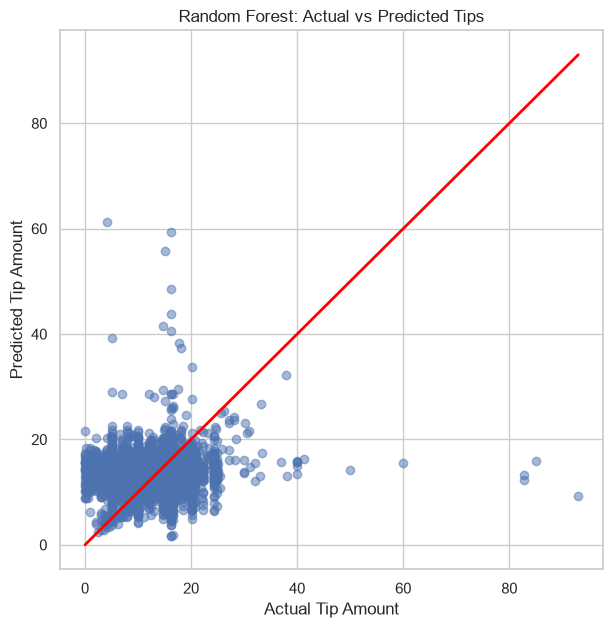

In [40]:
predictions = rf.predict(X_test_scaled)

plt.figure(figsize=(7,7))

plt.scatter(y_test, predictions, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.title("Random Forest: Actual vs Predicted Tips")

plt.show()

In [41]:
obesity = pd.read_csv(OBESITY_URL)

print("Shape:", obesity.shape)

display(obesity.head())

Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [42]:
obesity.info()

display(obesity.describe())

print("\nMissing Values")
display(obesity.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Missing Values


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


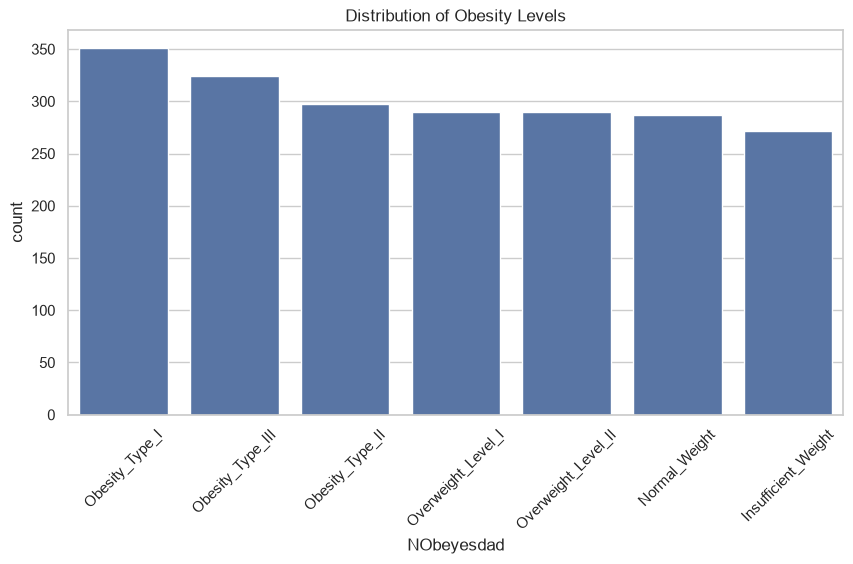

In [43]:
print(obesity["NObeyesdad"].value_counts())

plt.figure(figsize=(10,5))

sns.countplot(
    data=obesity,
    x="NObeyesdad",
    order=obesity["NObeyesdad"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Distribution of Obesity Levels")

plt.show()

I explored the obesity dataset by checking its dimensions, data types, summary statistics, and missing values. I also examined the distribution of the target variable (NObeyesdad). The seven obesity classes are reasonably balanced, with class sizes ranging from 272 to 351 samples. Since no class dominates the dataset, the classifier is less likely to become biased toward one class, making accuracy and macro F1-score more reliable evaluation metrics.

In [44]:
X = obesity.drop(columns=["NObeyesdad"])
y = obesity["NObeyesdad"]

print(X.shape)
print(y.shape)

(2111, 16)
(2111,)


In [45]:
# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Encode target labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print("Encoded feature shape:", X.shape)

Encoded feature shape: (2111, 23)


In [46]:
# 60% train, 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE
)

# Split temporary into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (1266, 23)
Validation: (422, 23)
Testing: (423, 23)


In [47]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(np.isnan(X_train_scaled).sum())
print(np.isnan(X_val_scaled).sum())
print(np.isnan(X_test_scaled).sum())

0
0
0


I separated the features from the target variable before preprocessing. The categorical input features were converted into numerical values using one-hot encoding, while the target labels were encoded using LabelEncoder. I used a stratified 60/20/20 split to preserve the class distribution across the training, validation, and test sets. Finally, I fitted the StandardScaler only on the training data and applied it to the validation and test sets to prevent data leakage and ensure an unbiased evaluation.

In [48]:
classifier = RandomForestClassifier(

    n_estimators=100,

    random_state=RANDOM_STATE

)

classifier.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [49]:
def evaluate_classifier(model, X, y, dataset):

    predictions = model.predict(X)

    accuracy = accuracy_score(y, predictions)

    f1 = f1_score(y, predictions, average="macro")

    print(dataset)

    print(f"Accuracy: {accuracy:.3f}")

    print(f"Macro F1: {f1:.3f}")

    print()

print("Random Forest Classifier\n")

evaluate_classifier(classifier, X_train_scaled, y_train, "Training")

evaluate_classifier(classifier, X_val_scaled, y_val, "Validation")

evaluate_classifier(classifier, X_test_scaled, y_test, "Testing")

Random Forest Classifier

Training
Accuracy: 1.000
Macro F1: 1.000

Validation
Accuracy: 0.927
Macro F1: 0.926

Testing
Accuracy: 0.934
Macro F1: 0.933



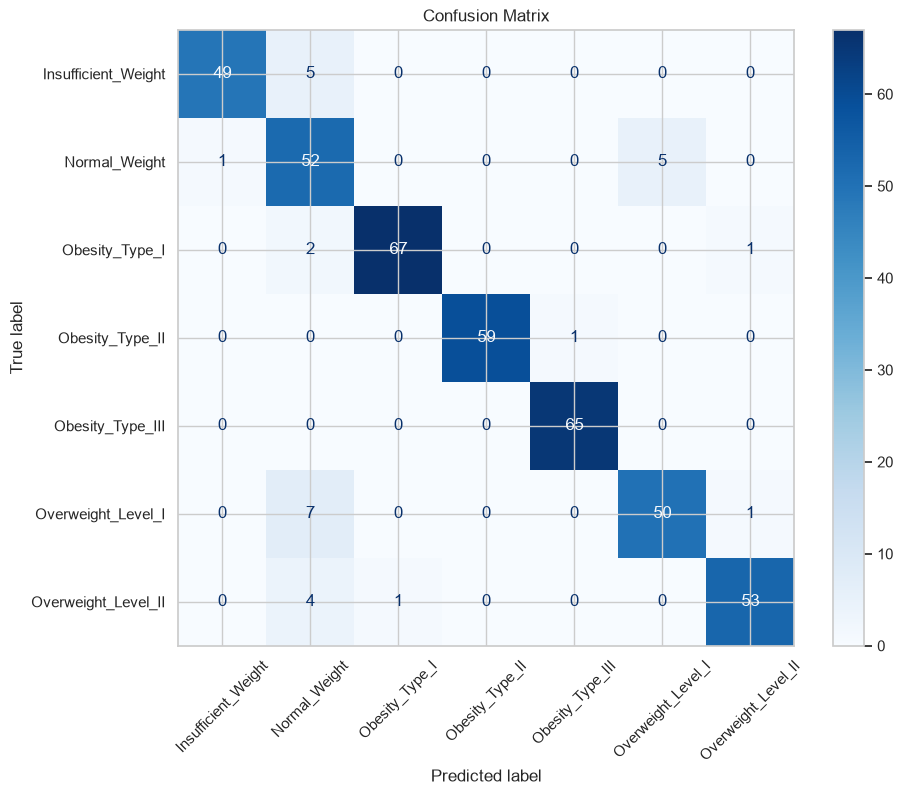

In [50]:
predictions = classifier.predict(X_test_scaled)

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(10,8))

disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix")

plt.show()

The Random Forest classifier achieved perfect performance on the training set, with an accuracy and macro F1-score of 1.000. On the validation and test sets, it achieved accuracies of 0.927 and 0.934, with macro F1-scores of 0.926 and 0.933, respectively. These results indicate slight overfitting because the training performance is perfect while the validation and test performance is slightly lower. However, the relatively small difference between the training and unseen datasets shows that the model generalizes well. If I wanted to reduce overfitting further, I could limit the tree depth, increase the minimum number of samples required to split a node, or tune additional hyperparameters using cross-validation.

In [51]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_train_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_train_scaled, cluster_labels)
    )

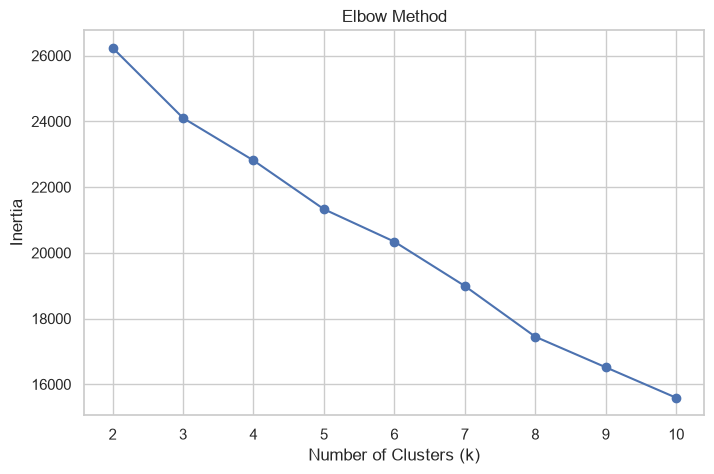

In [52]:
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

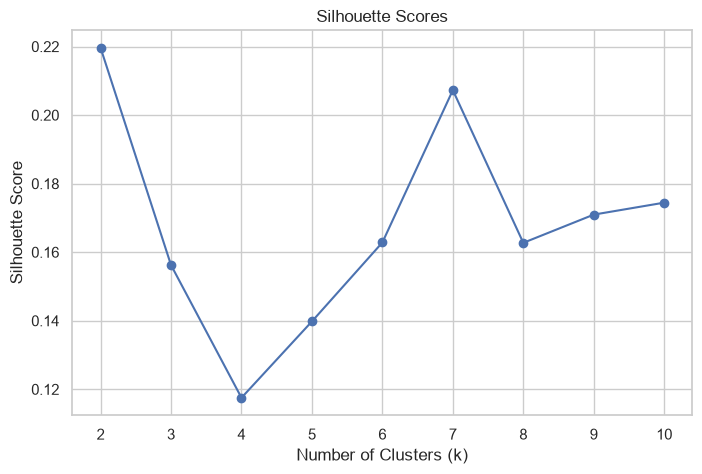

k = 2: 0.220
k = 3: 0.156
k = 4: 0.118
k = 5: 0.140
k = 6: 0.163
k = 7: 0.207
k = 8: 0.163
k = 9: 0.171
k = 10: 0.174


In [53]:
plt.figure(figsize=(8,5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Scores")

plt.show()

for k, score in zip(k_values, silhouette_scores):
    print(f"k = {k}: {score:.3f}")

In [ ]:
kmeans = KMeans(
    n_clusters=2,
    random_state=RANDOM_STATE,
    n_init=10
)

clusters = kmeans.fit_predict(X_train_scaled)

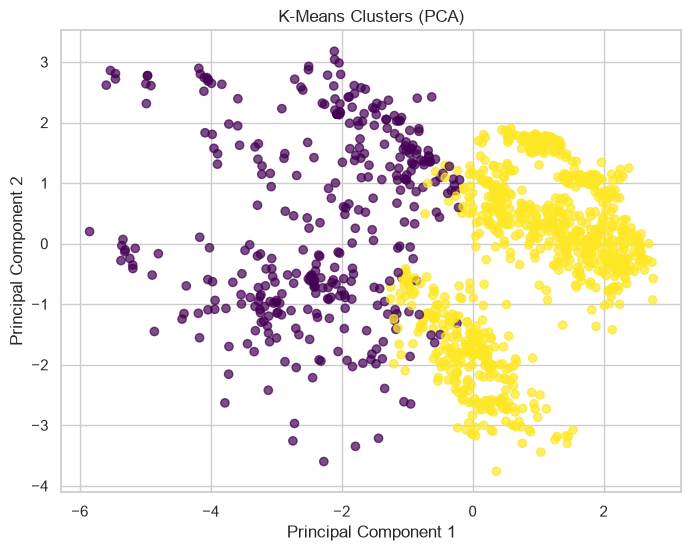

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    alpha=0.7
)

plt.title("K-Means Clusters (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [ ]:
cluster_comparison = pd.crosstab(
    clusters,
    label_encoder.inverse_transform(y_train),
    rownames=["Cluster"],
    colnames=["Actual Class"]
)

display(cluster_comparison)

Actual Class,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Cluster,,,,,,,
0,120,136,5,1,0,57,40
1,43,36,206,177,194,117,134


I selected k = 2 because it produced the highest silhouette score (0.220), indicating the best separation between clusters among the values tested. The elbow curve also showed that increasing the number of clusters resulted in diminishing improvements in inertia. After fitting K-Means and visualizing the clusters using PCA, I compared the cluster assignments with the true obesity classes using a crosstab. Since K-Means is an unsupervised algorithm, the clusters did not perfectly match the actual obesity categories, but they still revealed meaningful structure in the data by grouping individuals with similar characteristics.

REFLECTION:
1. What is the main difference between supervised and unsupervised learning?

Supervised learning uses labelled data to learn the relationship between input features and a known target variable. It is used for tasks such as regression and classification. Unsupervised learning uses unlabelled data and aims to discover hidden patterns or group similar observations without knowing the correct outputs beforehand.

⸻

2. How did regression, classification, and clustering differ in this lab?

In the regression task, the objective was to predict a continuous numerical value (tip_amount). In the classification task, the objective was to predict one of several obesity categories. In the clustering task, no target labels were used; instead, K-Means grouped similar observations based on their feature values to discover natural patterns in the data.

⸻

3. Why are validation and test sets important?

The validation set is used during model development to compare models and tune hyperparameters without affecting the final evaluation. The test set is kept completely unseen until the end and provides an unbiased estimate of how well the final model will perform on new data. Separating these datasets helps detect overfitting and ensures that model performance is evaluated fairly.

⸻

4. What did you learn about overfitting?

I learned that overfitting occurs when a model learns the training data too closely and performs much worse on unseen data. In this lab, the initial Random Forest regression model achieved excellent training performance but poor validation and test performance, indicating overfitting. After reducing the model complexity, the model generalized better across unseen data, demonstrating the importance of balancing model complexity with generalization.

⸻

5. Which model performed best overall, and why?

The Random Forest Classifier performed best overall. It achieved approximately 93% accuracy and a macro F1-score of 0.933 on the test set while maintaining similar performance on the validation set. This indicates that it generalized well to unseen data and was able to classify the obesity levels accurately. Although the regression models achieved lower predictive performance, the classification model demonstrated the strongest overall results in this lab.
